In [1]:
%run ../helper.py

In [2]:
import pandas as pd

Importing dataset

In [3]:
df = pd.read_csv("../data/data1.csv")

In [4]:
display(df)

,Year,Country,CountryCode,Variable,VariableCode,UnconsolidatedVariableCode,UnconsolidatedVariableName,Value,UnitType,Metadata
0,2010,Afghanistan,4,CIP score,cip,cip,CIP score,0.001880,I,NaN
1,2011,Afghanistan,4,CIP score,cip,cip,CIP score,0.001409,I,NaN
2,2012,Afghanistan,4,CIP score,cip,cip,CIP score,0.001426,I,NaN
3,2013,Afghanistan,4,CIP score,cip,cip,CIP score,0.001407,I,NaN
4,2014,Afghanistan,4,CIP score,cip,cip,CIP score,0.001190,I,NaN
...,...,...,...,...,...,...,...,...,...,...
36409,2019,Zimbabwe,716,Share of manufactured exports in total exports...,MXsh_index,MXsh_index,Share of manufactured exports in total exports...,0.474606,I,NaN
36410,2020,Zimbabwe,716,Share of manufactured exports in total exports...,MXsh_index,MXsh_index,Share of manufactured exports in total exports...,0.501063,I,NaN
36411,2021,Zimbabwe,716,Share of manufactured exports in total exports...,MXsh_index,MXsh_index,Share of manufactured exports in total exports...,0.505819,I,NaN
36412,2022,Zimbabwe,716,Share of manufactured exports in total exports...,MXsh_index,MXsh_index,Share of manufactured exports in total exports...,0.461505,I,NaN


Creating a country list, in this case Nordic countries

In [5]:
nordics = ['Denmark', 'Finland', 'Sweden', 'Norway', 'Iceland']

Filtering the data

In [6]:
df_nordics = df[df['Country'].isin(nordics)]

In [7]:
display(df_nordics)

,Year,Country,CountryCode,Variable,VariableCode,UnconsolidatedVariableCode,UnconsolidatedVariableName,Value,UnitType,Metadata
9996,2010,Denmark,208,CIP score,cip,cip,CIP score,0.185581,I,NaN
9997,2011,Denmark,208,CIP score,cip,cip,CIP score,0.183233,I,NaN
9998,2012,Denmark,208,CIP score,cip,cip,CIP score,0.177102,I,NaN
9999,2013,Denmark,208,CIP score,cip,cip,CIP score,0.180559,I,NaN
10000,2014,Denmark,208,CIP score,cip,cip,CIP score,0.178781,I,NaN
...,...,...,...,...,...,...,...,...,...,...
31411,2019,Sweden,752,Share of manufactured exports in total exports...,MXsh_index,MXsh_index,Share of manufactured exports in total exports...,0.910844,I,NaN
31412,2020,Sweden,752,Share of manufactured exports in total exports...,MXsh_index,MXsh_index,Share of manufactured exports in total exports...,0.900892,I,NaN
31413,2021,Sweden,752,Share of manufactured exports in total exports...,MXsh_index,MXsh_index,Share of manufactured exports in total exports...,0.905720,I,NaN
31414,2022,Sweden,752,Share of manufactured exports in total exports...,MXsh_index,MXsh_index,Share of manufactured exports in total exports...,0.889157,I,NaN


Including only the CIP score and the Nordics in the analysis:

In [8]:
df_nordic_cip = df[(df['Country'].isin(nordics)) & 
                   (df['Variable'] == 'CIP score')].copy()
#also, sorting by year
df_nordic_cip = df_nordic_cip.sort_values('Year')

Creating first visualization

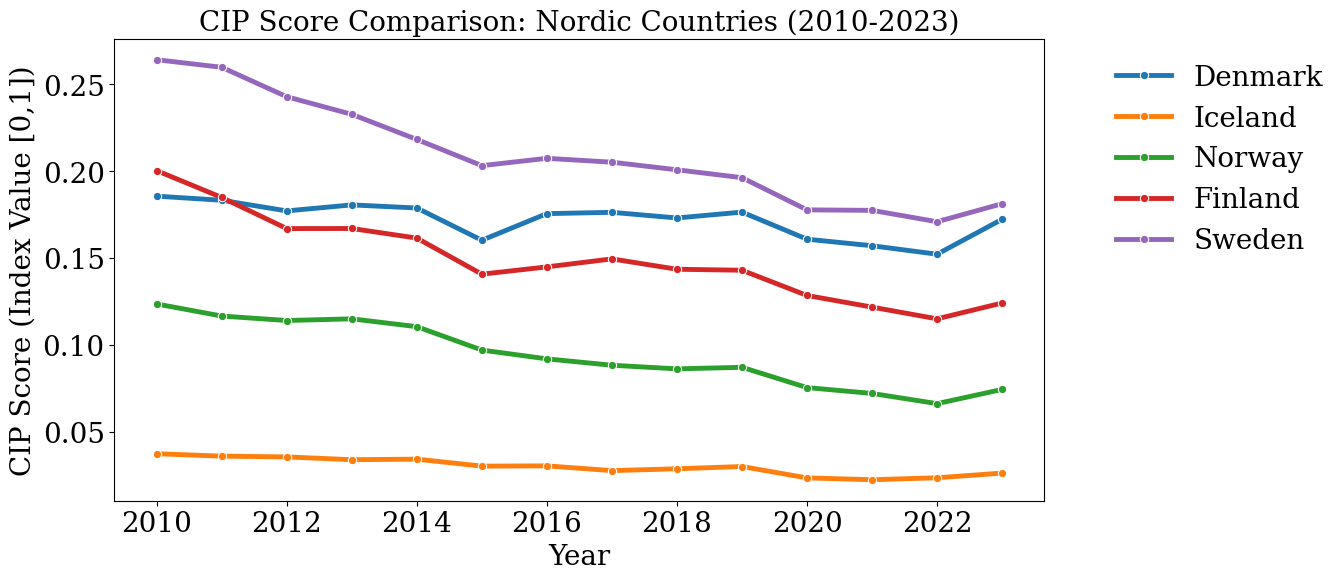

In [9]:
import seaborn as sns # Library for making statistical graphs
import matplotlib.pyplot as plt 

# Creating the figure
plt.figure(figsize=(12, 6))

# Plotting the data
sns.lineplot(
    data=df_nordic_cip, 
    x='Year', 
    y='Value', 
    hue='Country', 
    marker='o',      # Dot for each year in the time series
    linewidth=3.5    # Line width
)

# Customizing the layout
plt.title("CIP Score Comparison: Nordic Countries (2010-2023)")
plt.ylabel("CIP Score (Index Value [0,1])")
plt.xlabel("Year")
# plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Move the legend outside if it overlaps the data
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Save the high-quality figure to your figures folder
plt.savefig("../figures/nordic_cip_timeseries_1st.png", dpi=300, bbox_inches='tight')

# Show the plot in the notebook
plt.show()

Changes to the initial image to make it fulfill Tufte principles:

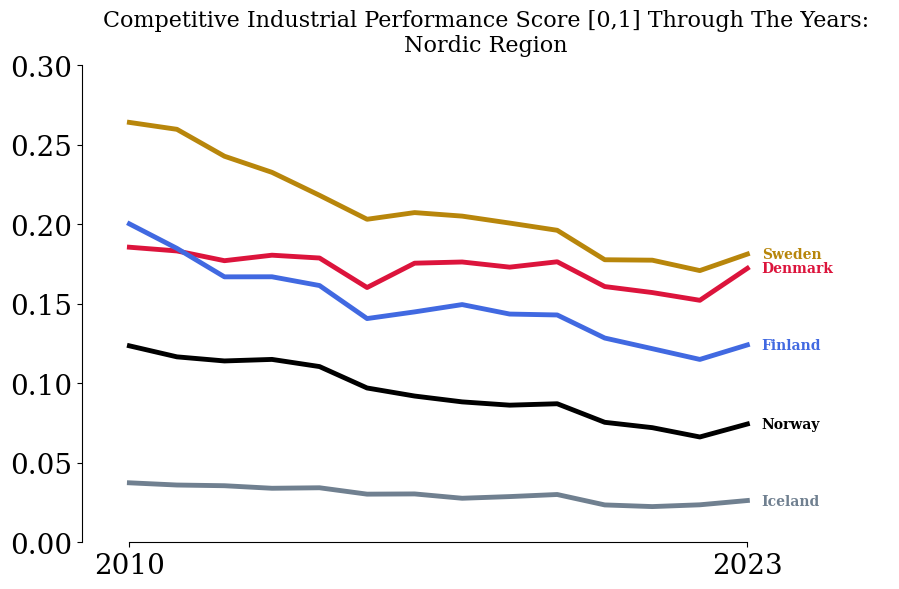

In [10]:
# Define colors
country_colors = {
    'Sweden': 'darkgoldenrod',
    'Denmark': 'crimson',
    'Finland': 'royalblue',
    'Iceland': 'slategrey',
    'Norway': 'black'
}

# Creating the figure
fig, ax = plt.subplots(1,1, figsize=(12,6))

# Plotting the data
sns.lineplot(
    data=df_nordic_cip, 
    x='Year', 
    y='Value', 
    hue='Country',
    palette=country_colors,
    #marker='o',      # Dot for each year in the time series
    linewidth=3.5    # Line width
)

# Modifying axes to be simpler 
ax.set_xticks(np.arange(2010,2024,13))
ax.set_yticks(np.arange(0.00,0.35,0.05))
ax.set_xlabel("")
ax.set_ylabel("")

# Title split into two lines
plt.title("Competitive Industrial Performance Score [0,1] Through The Years:\nNordic Region", 
          fontsize=16, 
          fontweight='light', 
          pad=10)

# Customizing the layout
# plt.title("Competitive Industrial Performance Scores [0,1] through the years: Nordic Countries")
# plt.ylabel("CIP Score (Index Value [0,1])")
# plt.xlabel("Year")
# plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Move the legend outside if it overlaps the data
plt.legend(bbox_to_anchor=(1.05, 0.7), loc='upper left')


# Clean finish, trim the axes and image spine
sns.despine(fig, trim=True) # Removes top and right spines
plt.tight_layout()

# Getting rid of legends, showing country name next to time series line
# Defining the final year in the dataset
final_year = 2023

# Iterating through countries to place text
for country, color in country_colors.items():
    # Filter data for the specific country
    subset = df_nordic_cip[df_nordic_cip['Country'] == country]
    
    # Get the value for the final year
    # Ensure the country has data for that year
    if not subset[subset['Year'] == final_year].empty:
        y_val = subset[subset['Year'] == final_year]['Value'].values[0]
        
        # Place the text
        ax.text(
            x=final_year + 0.3,  # Offset to the right of the last point
            y=y_val, 
            s=country, 
            color=color,         # Matches line color
            va='center',         # Vertical alignment
            fontweight='bold',
            fontsize=10
        )

# Remove the now redundant legend
ax.get_legend().remove()

# Extend the X-axis limit to make room for the labels
ax.set_xlim(2009, 2026)

# Save the high-quality figure to your figures folder
plt.savefig("../figures/nordic_cip_timeseries_2nd.png", dpi=300, bbox_inches='tight')

# Show the plot in the notebook
plt.show()

Including more years to the analysis to make it more interesting

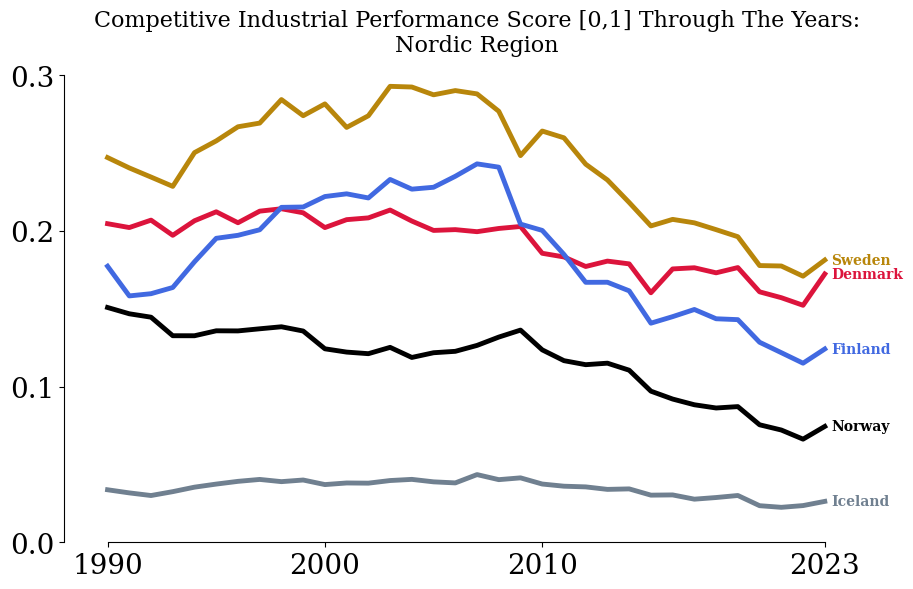

In [11]:
# Define colors
country_colors = {
    'Sweden': 'darkgoldenrod',
    'Denmark': 'crimson',
    'Finland': 'royalblue',
    'Iceland': 'slategrey',
    'Norway': 'black'
}
    
# New data
df_new = pd.read_csv("../data/data2nordics.csv")

# Wrangling
df_new_cip = df_new[(df_new['Variable'] == 'CIP score')].copy()
#also, sorting by year
df_new_cip = df_new_cip.sort_values('Year')

# Creating the figure
fig, ax = plt.subplots(1,1, figsize=(12,6))

# Plotting the data
sns.lineplot(
    data=df_new_cip, 
    x='Year', 
    y='Value', 
    hue='Country',
    palette=country_colors,
    #marker='o',      # Dot for each year in the time series
    linewidth=3.5    # Line width
)

# Modifying axes to be simpler 
#ax.set_xticks(np.arange(1990,2023,10))
ax.set_xticks([1990, 2000, 2010, 2023])
ax.set_yticks(np.arange(0.00,0.35,0.1))
ax.set_xlabel("")
ax.set_ylabel("")

# Title split into two lines
plt.title("Competitive Industrial Performance Score [0,1] Through The Years:\nNordic Region", 
          fontsize=16, 
          fontweight='light', 
          pad=10)

# Customizing the layout
# plt.title("Competitive Industrial Performance Scores [0,1] through the years: Nordic Countries")
# plt.ylabel("CIP Score (Index Value [0,1])")
# plt.xlabel("Year")
# plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Moving the legend outside if it overlaps the data
plt.legend(bbox_to_anchor=(1.05, 0.7), loc='upper left')


# Clean finish, trim the axes and image spine
sns.despine(fig, trim=True) # Removes top and right spines
plt.tight_layout()

# Getting rid of legends, showing country name next to time series line
# Defining the final year in the dataset
final_year = 2023

# Iterating through countries to place text
for country, color in country_colors.items():
    # Filter data for the specific country
    subset = df_new_cip[df_new_cip['Country'] == country]
    
    # Get the value for the final year
    # Ensure the country has data for that year
    if not subset[subset['Year'] == final_year].empty:
        y_val = subset[subset['Year'] == final_year]['Value'].values[0]
        
        # Place the text
        ax.text(
            x=final_year + 0.3,  # Offset to the right of the last point
            y=y_val, 
            s=country, 
            color=color,         # Matches line color
            va='center',         # Vertical alignment
            fontweight='bold',
            fontsize=10
        )

# Remove the now redundant legend
ax.get_legend().remove()

# Extend the X-axis limit to make room for the labels
ax.set_xlim(1988, 2026)

# Save the high-quality figure to your figures folder
plt.savefig("../figures/nordic_cip_timeseries.png", dpi=300, bbox_inches='tight')

# Show the plot in the notebook
plt.show()

In [12]:
display(df_new_cip)

,Year,Country,CountryCode,Variable,VariableCode,UnconsolidatedVariableCode,UnconsolidatedVariableName,Value,UnitType,Metadata
0,1990,Denmark,208,CIP score,cip,cip,CIP score,0.204584,I,NaN
272,1990,Sweden,752,CIP score,cip,cip,CIP score,0.247053,I,NaN
68,1990,Finland,246,CIP score,cip,cip,CIP score,0.177264,I,NaN
204,1990,Norway,578,CIP score,cip,cip,CIP score,0.150779,I,NaN
136,1990,Iceland,352,CIP score,cip,cip,CIP score,0.033719,I,NaN
...,...,...,...,...,...,...,...,...,...,...
237,2023,Norway,578,CIP score,cip,cip,CIP score,0.074393,I,NaN
101,2023,Finland,246,CIP score,cip,cip,CIP score,0.124131,I,NaN
33,2023,Denmark,208,CIP score,cip,cip,CIP score,0.172290,I,NaN
169,2023,Iceland,352,CIP score,cip,cip,CIP score,0.026266,I,NaN
